### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [ ]:
ingreso_1 = tienda1["Precio"].sum()
ingreso_2 = tienda2["Precio"].sum()
ingreso_3 = tienda3["Precio"].sum()
ingreso_4 = tienda4["Precio"].sum()

In [ ]:
print(f"Ingreso total de la tienda 1: ${ingreso_1}")
print(f"Ingreso total de la tienda 2: ${ingreso_2}")
print(f"Ingreso total de la tienda 3: ${ingreso_3}")
print(f"Ingreso total de la tienda 4: ${ingreso_4}")


Ingreso total de la tienda 1: $1150880400.0
Ingreso total de la tienda 2: $1116343500.0
Ingreso total de la tienda 3: $1098019600.0
Ingreso total de la tienda 4: $1038375700.0


# 2. Ventas por categoría

In [ ]:
# 1. Calculamos los ingresos y los convertimos a millones para que la tabla sea legible
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos_millones = [
    tienda1['Precio'].sum() / 1_000_000,
    tienda2['Precio'].sum() / 1_000_000,
    tienda3['Precio'].sum() / 1_000_000,
    tienda4['Precio'].sum() / 1_000_000
]

# Tu código para crear la tabla:
datos_ingresos_totales = pd.DataFrame(ingresos_millones, index=tiendas)
datos_ingresos_totales.rename(columns={0:"Ingreso en millones"}, inplace=True)
datos_ingresos_totales

,Ingreso en millones
Tienda 1,1150.8804
Tienda 2,1116.3435
Tienda 3,1098.0196
Tienda 4,1038.3757


In [ ]:
ventas_categoria_1 = tienda1.groupby("Categoría del Producto")["Producto"].count().sort_values(ascending=False)
ventas_categoria_2 = tienda2.groupby("Categoría del Producto")["Producto"].count().sort_values(ascending=False)
ventas_categoria_3 = tienda3.groupby("Categoría del Producto")["Producto"].count().sort_values(ascending=False)
ventas_categoria_4 = tienda4.groupby("Categoría del Producto")["Producto"].count().sort_values(ascending=False)
datos_ventas_categoria = pd.DataFrame({"Tienda 1": ventas_categoria_1,
                                       "Tienda 2": ventas_categoria_2,
                                       "Tienda 3": ventas_categoria_3,
                                       "Tienda 4": ventas_categoria_4
                                       })
datos_ventas_categoria


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


# 3. Calificación promedio de la tienda


In [ ]:
# Esta es CLAVE para ver si los clientes están contentos
print(f"T1: {tienda1['Calificación'].mean():.2f}")
print(f"T2: {tienda2['Calificación'].mean():.2f}")
print(f"T3: {tienda3['Calificación'].mean():.2f}")
print(f"T4: {tienda4['Calificación'].mean():.2f}")

T1: 3.98
T2: 4.04
T3: 4.05
T4: 4.00


# 4. Productos más y menos vendidos

In [ ]:
productos_1 = tienda1.groupby("Producto")["Producto"].count().sort_values(ascending=False)
productos_2 = tienda2.groupby("Producto")["Producto"].count().sort_values(ascending=False)
productos_3 = tienda3.groupby("Producto")["Producto"].count().sort_values(ascending=False)
productos_4 = tienda4.groupby("Producto")["Producto"].count().sort_values(ascending=False)

productos = pd.concat([productos_1, productos_2, productos_3, productos_4], axis=1)
productos.columns = tiendas

productos


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,,,,
Armario,60,54,49,34
TV LED UHD 4K,60,45,42,40
Microondas,60,62,36,48
Secadora de ropa,58,57,45,40
Mesa de noche,56,44,55,55
Bloques de construcción,56,54,35,54
Balón de baloncesto,55,42,50,50
Bicicleta,54,45,52,45
Impresora,54,34,50,50


# 5. Envío promedio por tienda

In [ ]:
# Si el envío es muy caro, el Sr. Juan pierde dinero
print(f"Costo Envío T1: ${tienda1['Costo de envío'].mean():,.0f}")
print(f"Costo Envío T2: ${tienda2['Costo de envío'].mean():,.0f}")
print(f"Costo Envío T3: ${tienda3['Costo de envío'].mean():,.0f}")
print(f"Costo Envío T4: ${tienda4['Costo de envío'].mean():,.0f}")

Costo Envío T1: $26,019
Costo Envío T2: $25,216
Costo Envío T3: $24,806
Costo Envío T4: $23,459


GRÁFICOS

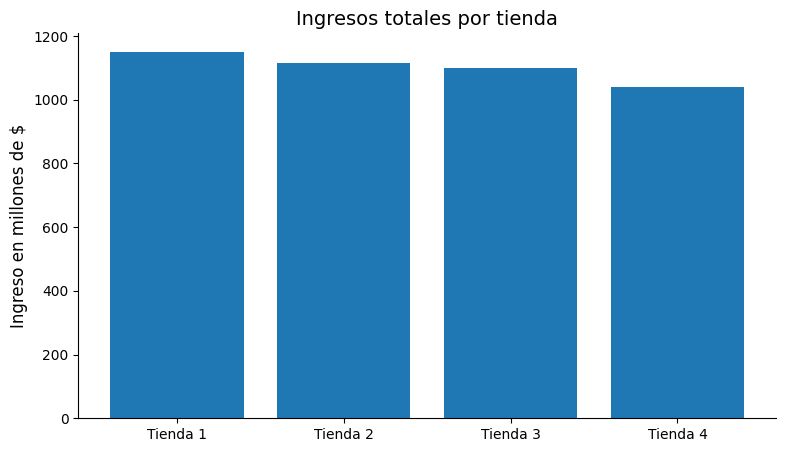

In [ ]:
import matplotlib.pyplot as plt


tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
ingresos = [ingreso_1, ingreso_2, ingreso_3, ingreso_4]
ingresos_millones = [i / 1000000 for i in ingresos]

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(tiendas, ingresos_millones)
ax.set_title("Ingresos totales por tienda", fontsize=14)
ax.set_ylabel("Ingreso en millones de $", fontsize=12)
ax.spines[["top","right"]].set_visible(False)

plt.show()

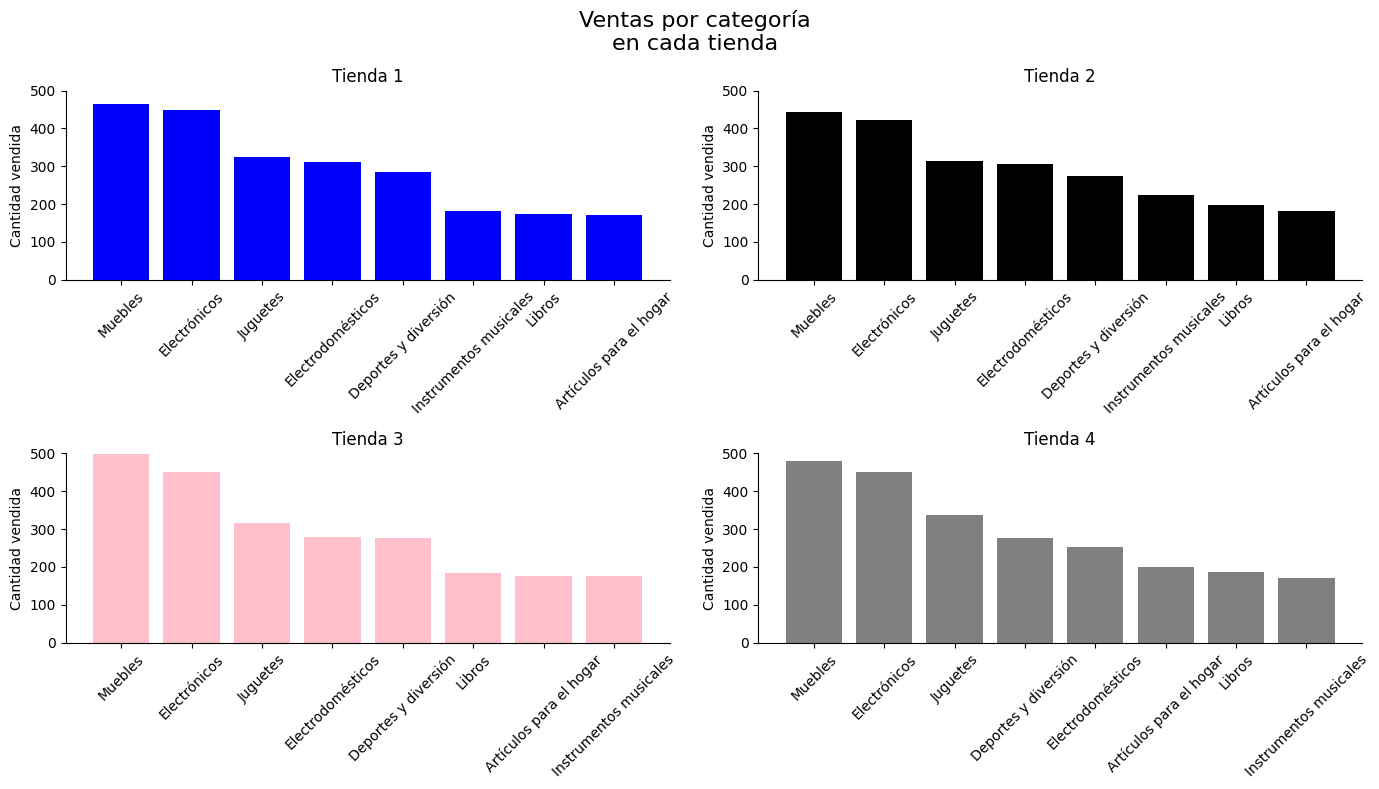

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Ventas por categoría\nen cada tienda",fontsize=16)

axs[0, 0].bar(ventas_categoria_1.index, ventas_categoria_1.values, color='blue')
axs[0, 0].set_title('Tienda 1')
axs[0, 0].tick_params(axis='x', rotation=45)

axs[0, 1].bar(ventas_categoria_2.index, ventas_categoria_2.values, color='black')
axs[0, 1].set_title('Tienda 2')
axs[0, 1].tick_params(axis='x', rotation=45)

axs[1, 0].bar(ventas_categoria_3.index, ventas_categoria_3.values, color='pink')
axs[1, 0].set_title('Tienda 3')
axs[1, 0].tick_params(axis='x', rotation=45)

axs[1, 1].bar(ventas_categoria_4.index, ventas_categoria_4.values, color='gray')
axs[1, 1].set_title('Tienda 4')
axs[1, 1].tick_params(axis='x', rotation=45)

for ax in axs.flat:
  ax.spines[["top","right"]].set_visible(False)
  ax.set_ylabel('Cantidad vendida')
  ax.tick_params(axis='x', rotation=45)
  ax.set_ylim(0,500)

plt.tight_layout()
plt.show()

ANÁLISIS

Tras un análisis de las cuatro unidades de negocio, se concluye que la Tienda 4 es la candidata principal para la venta. Los argumentos técnicos son los siguientes:

Bajo Rendimiento Financiero: A pesar de operar en un mercado con valoraciones estables (4 estrellas), la Tienda 4 registra consistentemente los ingresos totales más bajos. Esto indica una falta de tracción comercial o una demanda insuficiente en su ubicación actual.

Paradoja Logística: Si bien presenta el costo de envío más bajo, esta eficiencia no logra compensar la debilidad en las ventas. Una logística económica en un entorno de bajos ingresos no genera una economía de escala suficiente para maximizar el lucro.

Debilidad en Categorías Clave: El análisis de inventario mostró que es la tienda con menor movimiento en categorías de alto valor, lo que limita su capacidad de crecimiento orgánico a corto plazo.

Veredicto: La venta de la Tienda 4 permitirá al señor Juan liquidar un activo de bajo crecimiento y reasignar ese capital a proyectos con un mayor Retorno de Inversión (ROI).